In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 랜덤 초기화
np.random.seed(42)

# 폰트 설정 : 한글깨짐을 방지하기 위해
# colab에서는 
plt.rcParams['font.family'] = 'Malgun gothic'
plt.rcParams['axes.unicode_minus'] = False # -(마이너스) 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 300

In [3]:
#california.csv 읽어와서 상위 3개 출력하기

df = pd.read_csv('data/california.csv')

df.head(3)



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,17000.0,-119.562108,2.005166,-124.3500,-121.790000,-118.4900,-118.000,-114.3100
latitude,17000.0,35.625225,2.137340,32.5400,33.930000,34.2500,37.720,41.9500
housing_median_age,17000.0,28.589353,12.586937,1.0000,18.000000,29.0000,37.000,52.0000
total_rooms,17000.0,2643.664412,2179.947071,2.0000,1462.000000,2127.0000,3151.250,37937.0000
total_bedrooms,17000.0,539.410824,421.499452,1.0000,297.000000,434.0000,648.250,6445.0000
population,17000.0,1429.573941,1147.852959,3.0000,790.000000,1167.0000,1721.000,35682.0000
households,17000.0,501.221941,384.520841,1.0000,282.000000,409.0000,605.250,6082.0000
median_income,17000.0,3.883578,1.908157,0.4999,2.566375,3.5446,4.767,15.0001
median_house_value,17000.0,207300.912353,115983.764387,14999.0000,119400.000000,180400.0000,265000.000,500001.0000


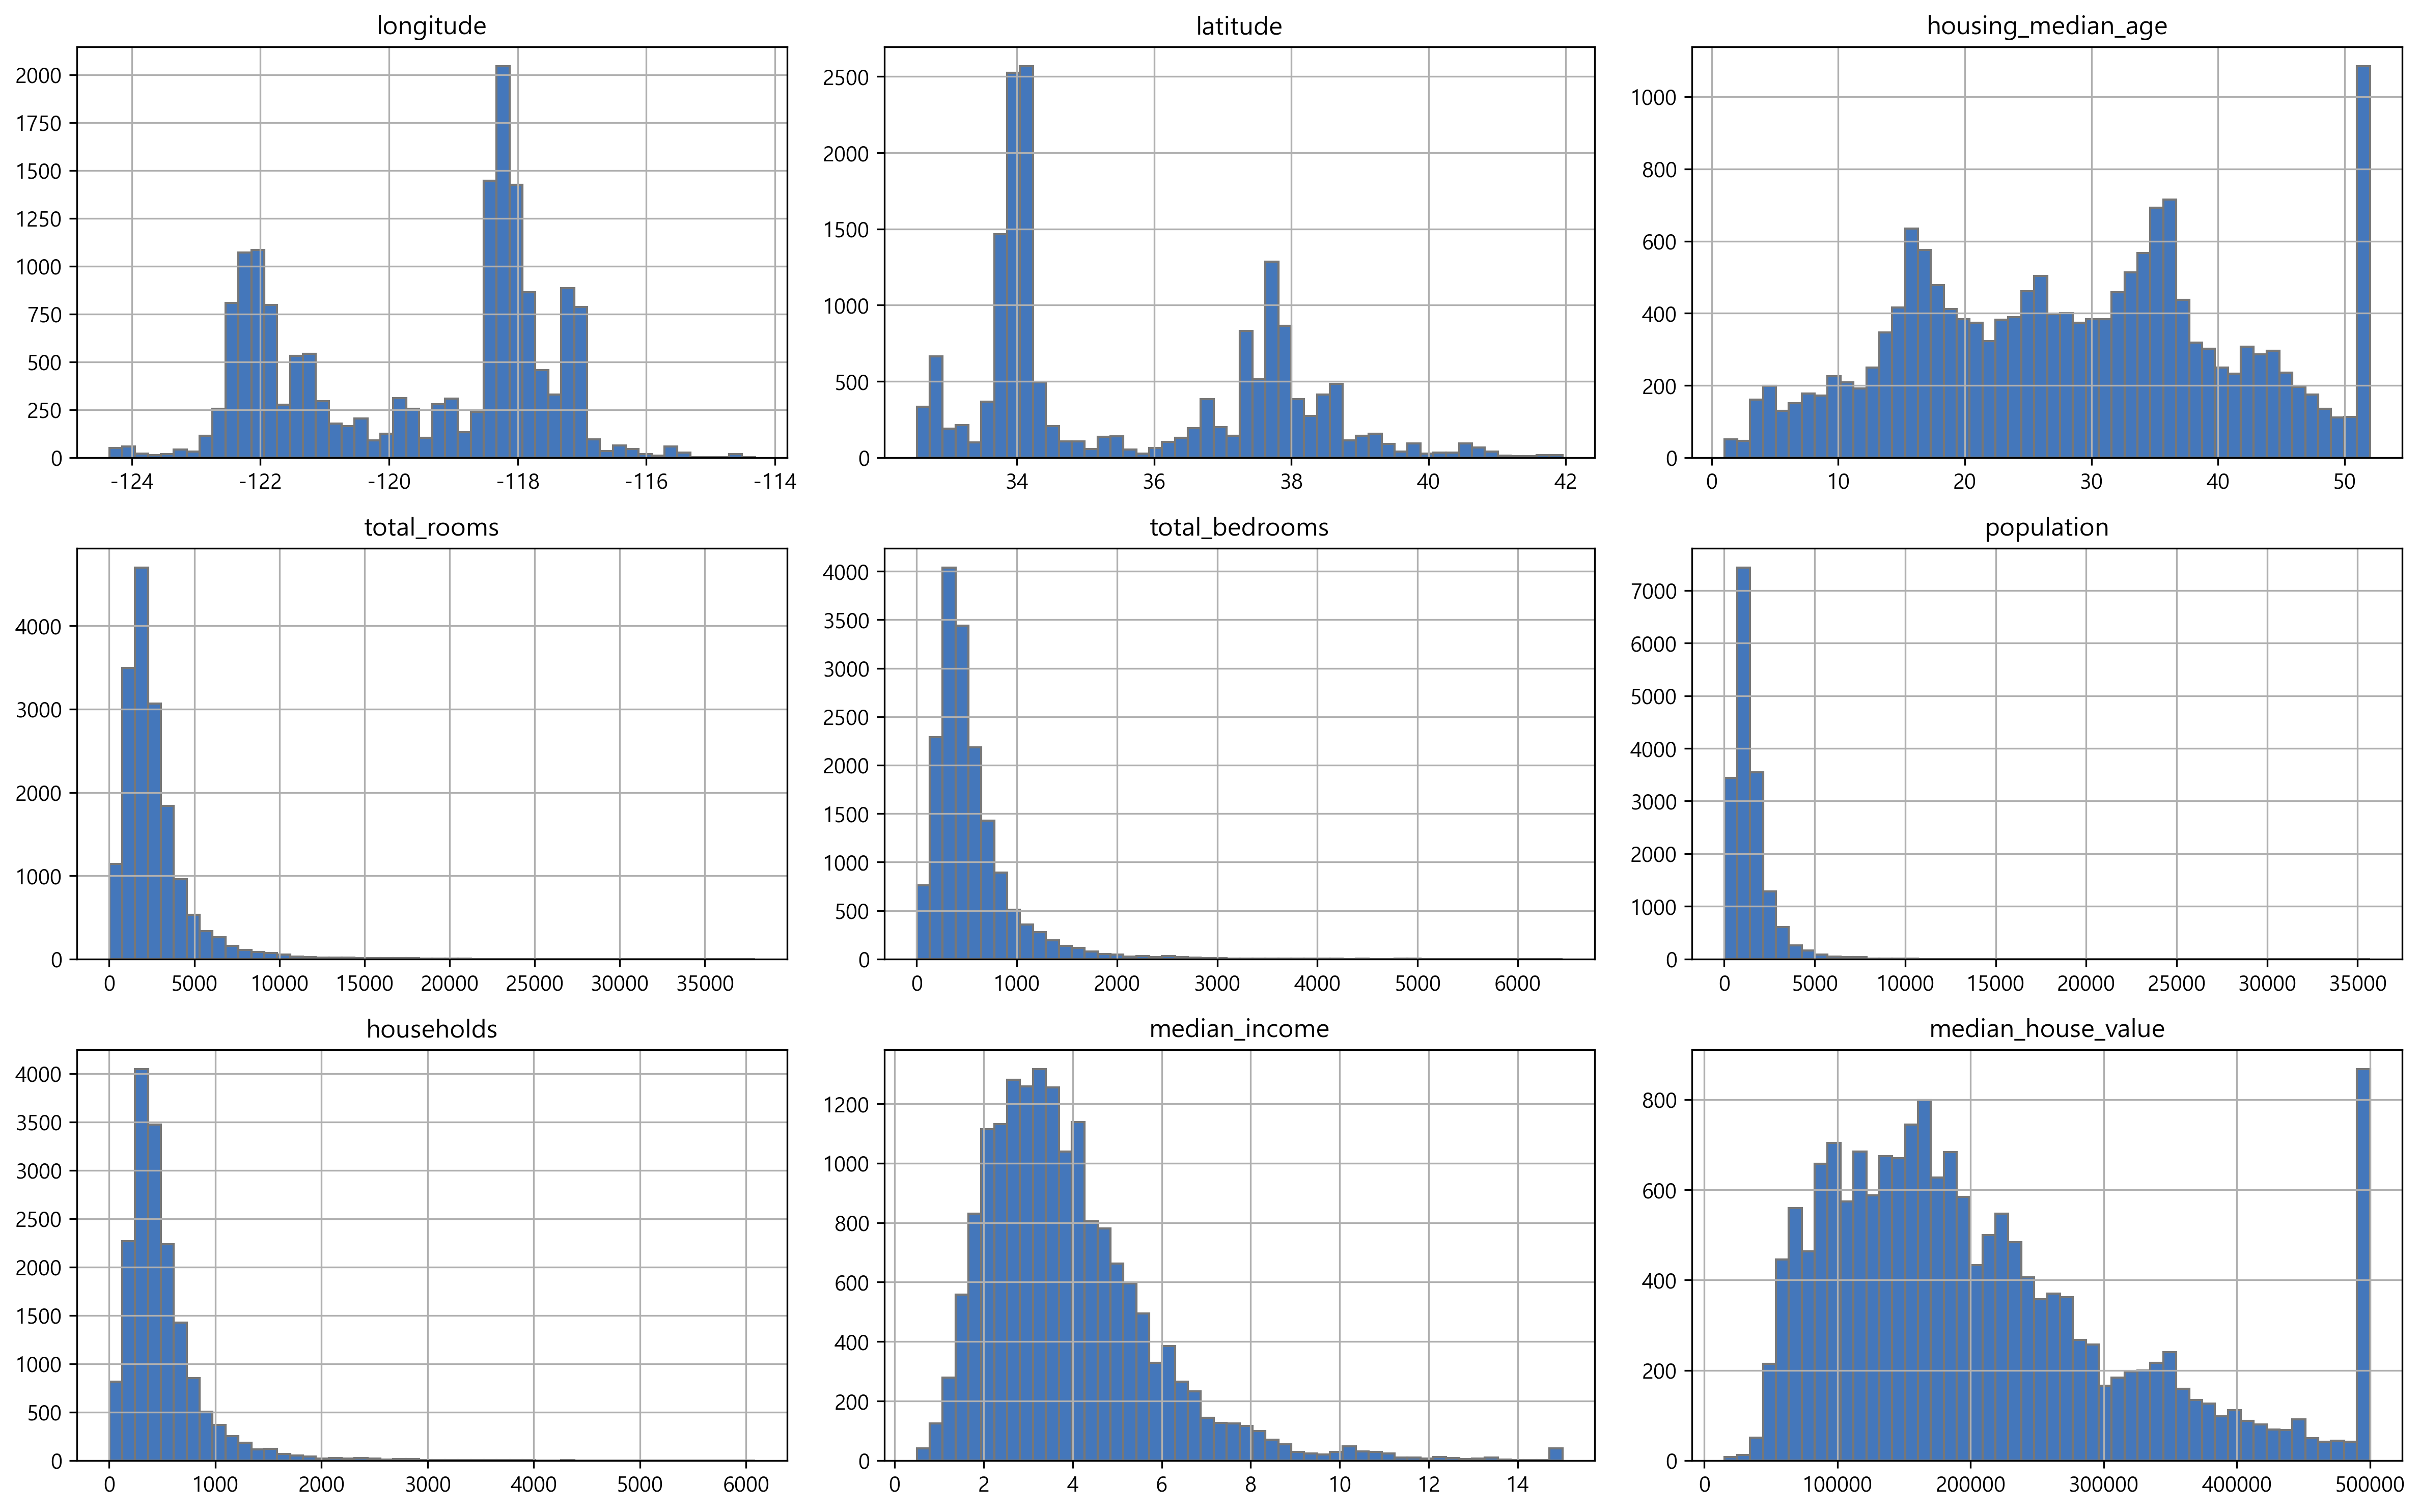

In [6]:
# 시간적 데이터 한번에 파악하기

df.hist(
    bins=50,
    figsize=(16, 10),
    color='#4477bb',
    edgecolor='#777777'
)

plt.tight_layout()
plt.show()


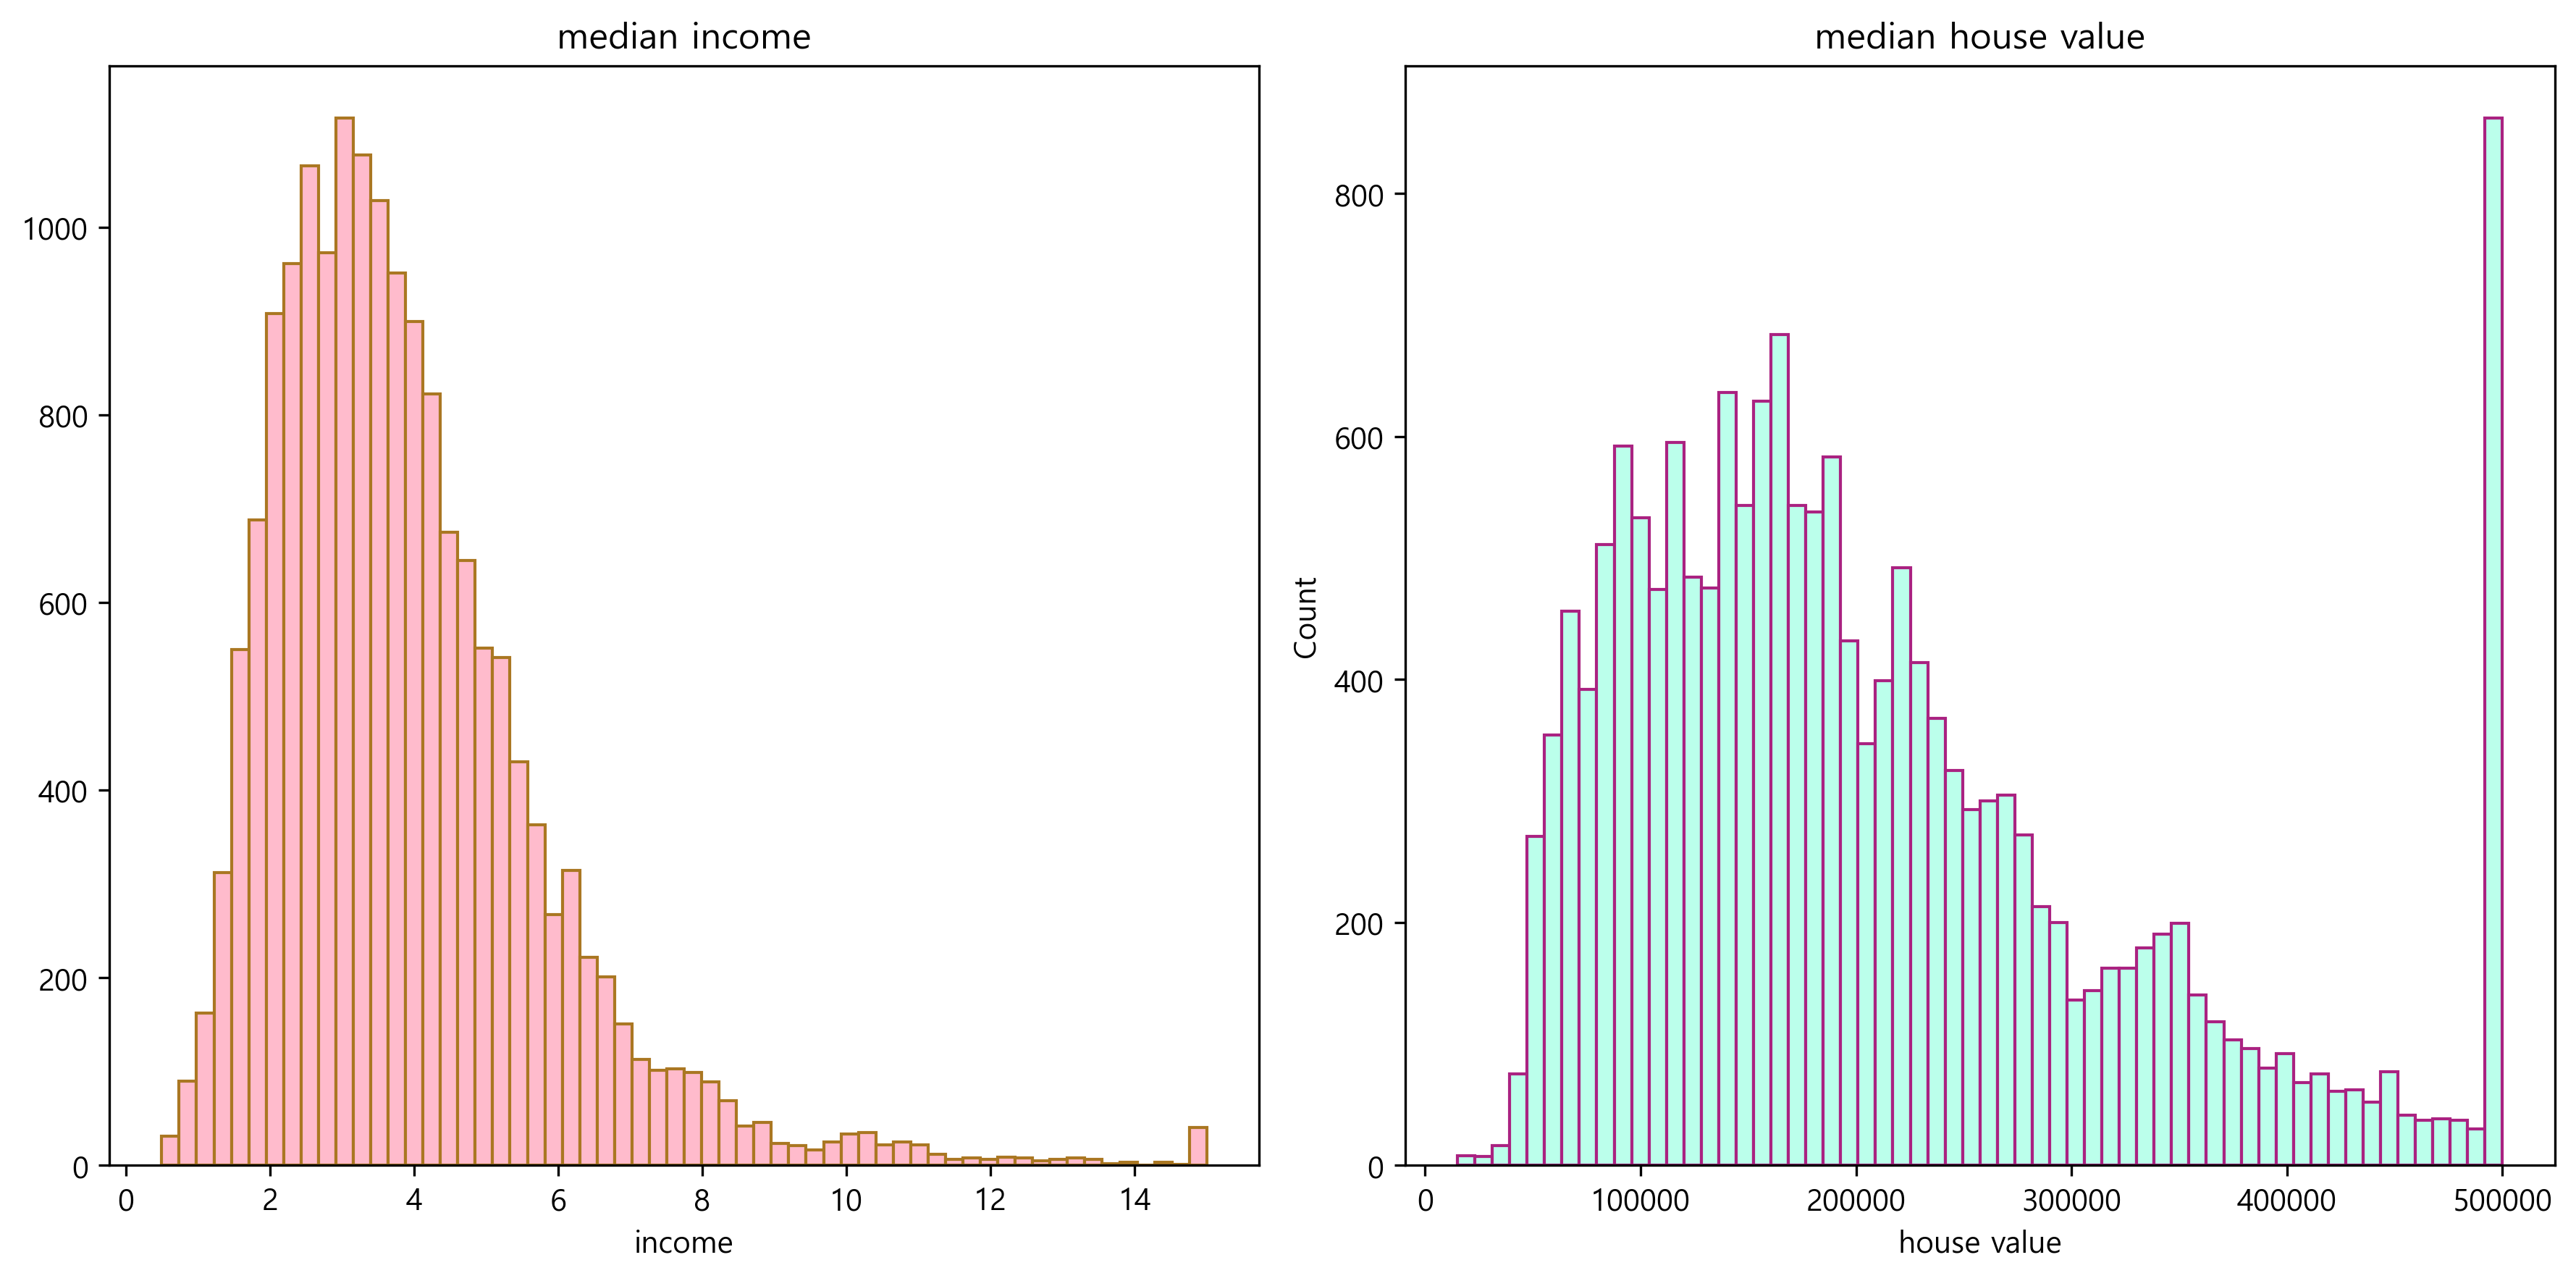

In [7]:
# median income vs median house value의 분포 확인하기

fig, axes = plt.subplots(1,2,figsize=(12,6))

axes[0].hist(df['median_income'],bins=60, color='#ffbbcc',edgecolor='#aa7722')
axes[0].set_title('median income')
axes[0].set_xlabel('income')
axes[1].set_xlabel('Count')
axes[1].hist(df['median_house_value'],bins=60, color="#bbffeb",edgecolor="#aa2281")
axes[1].set_title('median house value')
axes[1].set_xlabel('house value')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

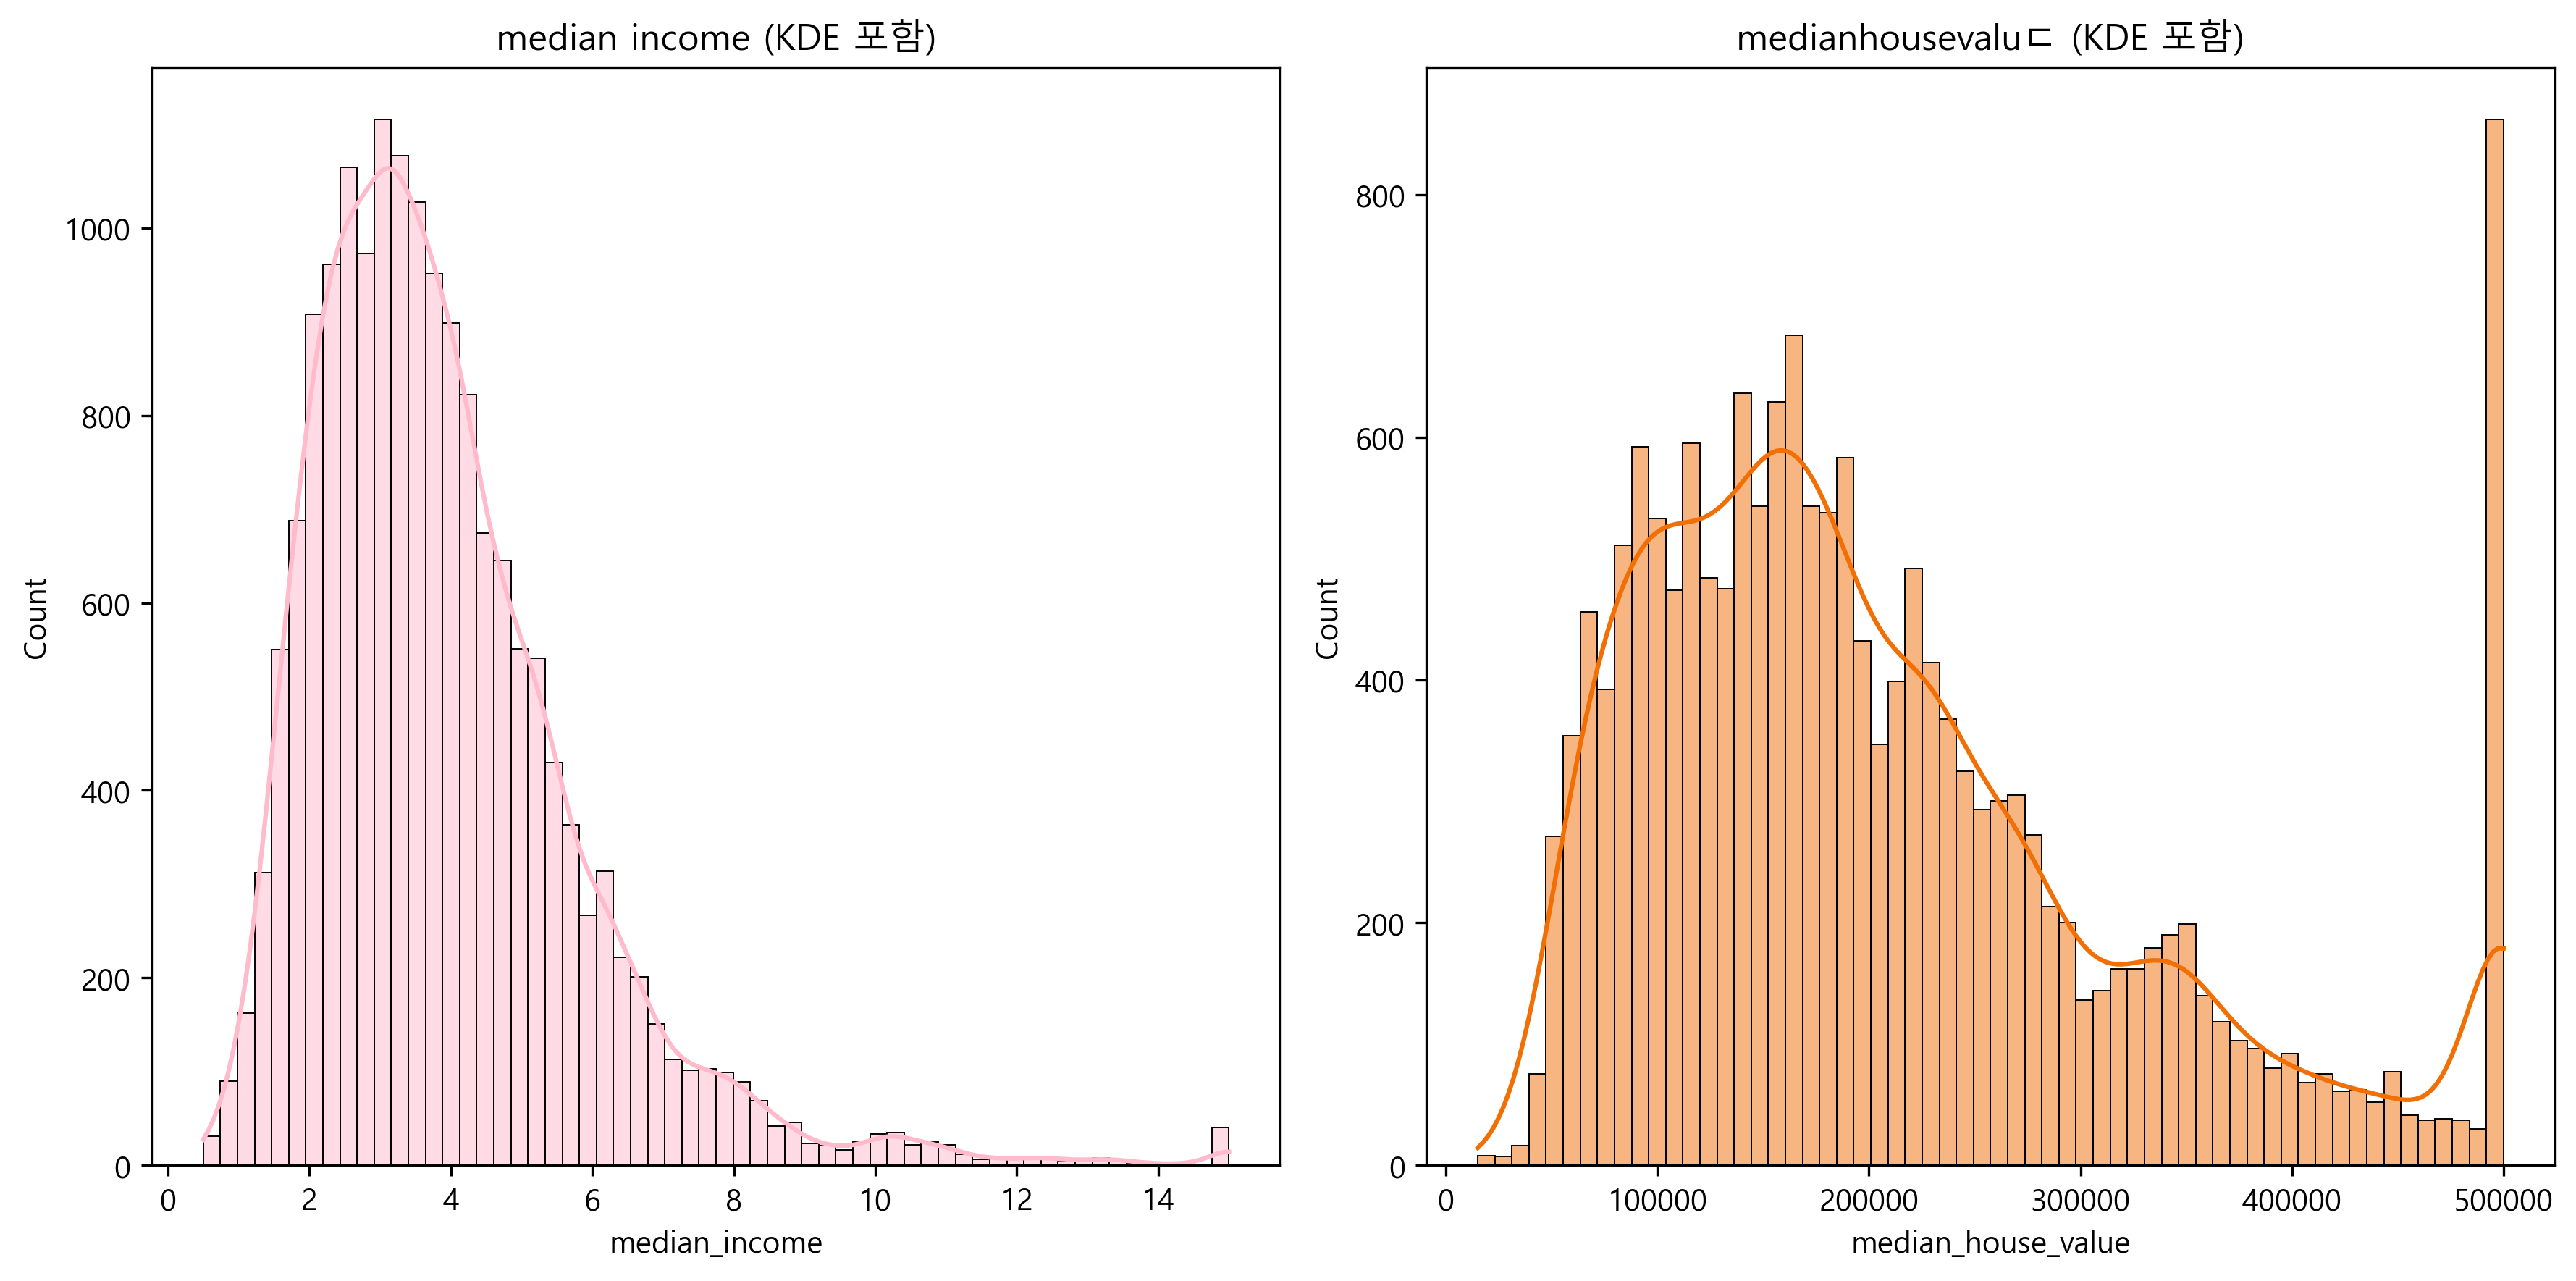

In [8]:
fig, axes = plt.subplots(1,2,figsize=(12,6))

sns.histplot(df['median_income'],bins=60, kde=True, color='#ffbbcc', ax=axes[0])
axes[0].set_title('median income (KDE 포함)')
sns.histplot(df['median_house_value'],bins=60, kde=True, color="#f16f05", ax=axes[1])
axes[1].set_title('medianhousevaluㄷ (KDE 포함)')
plt.tight_layout()
plt.show()

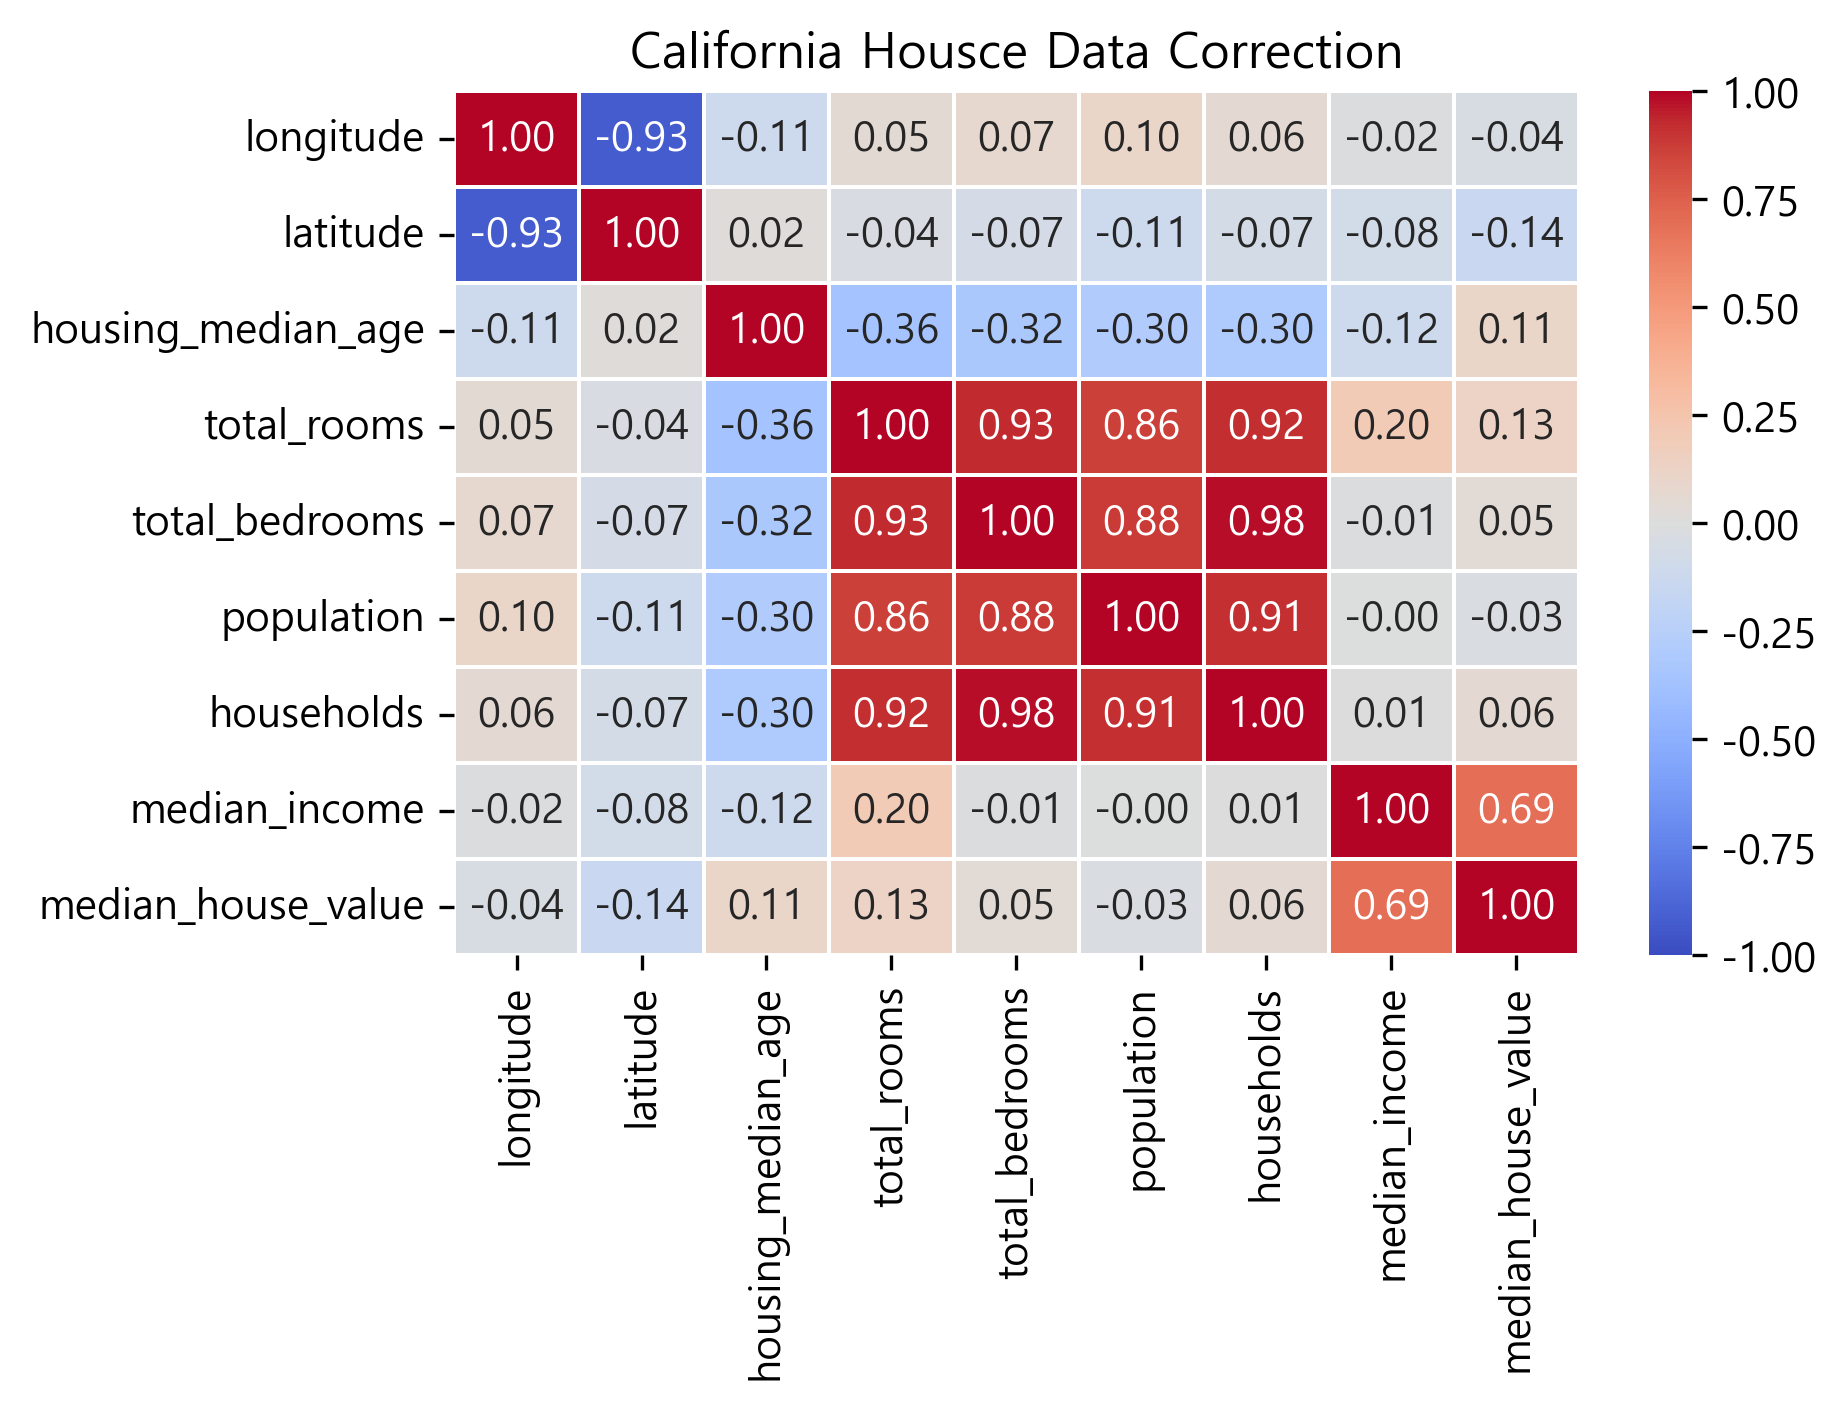

In [9]:
corr = df.corr()

sns.heatmap(corr, annot=True, fmt='.2f',cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            linewidths=0.5,linewidth=0.5)
plt.title('California Housce Data Correction')
plt.tight_layout()
plt.show()


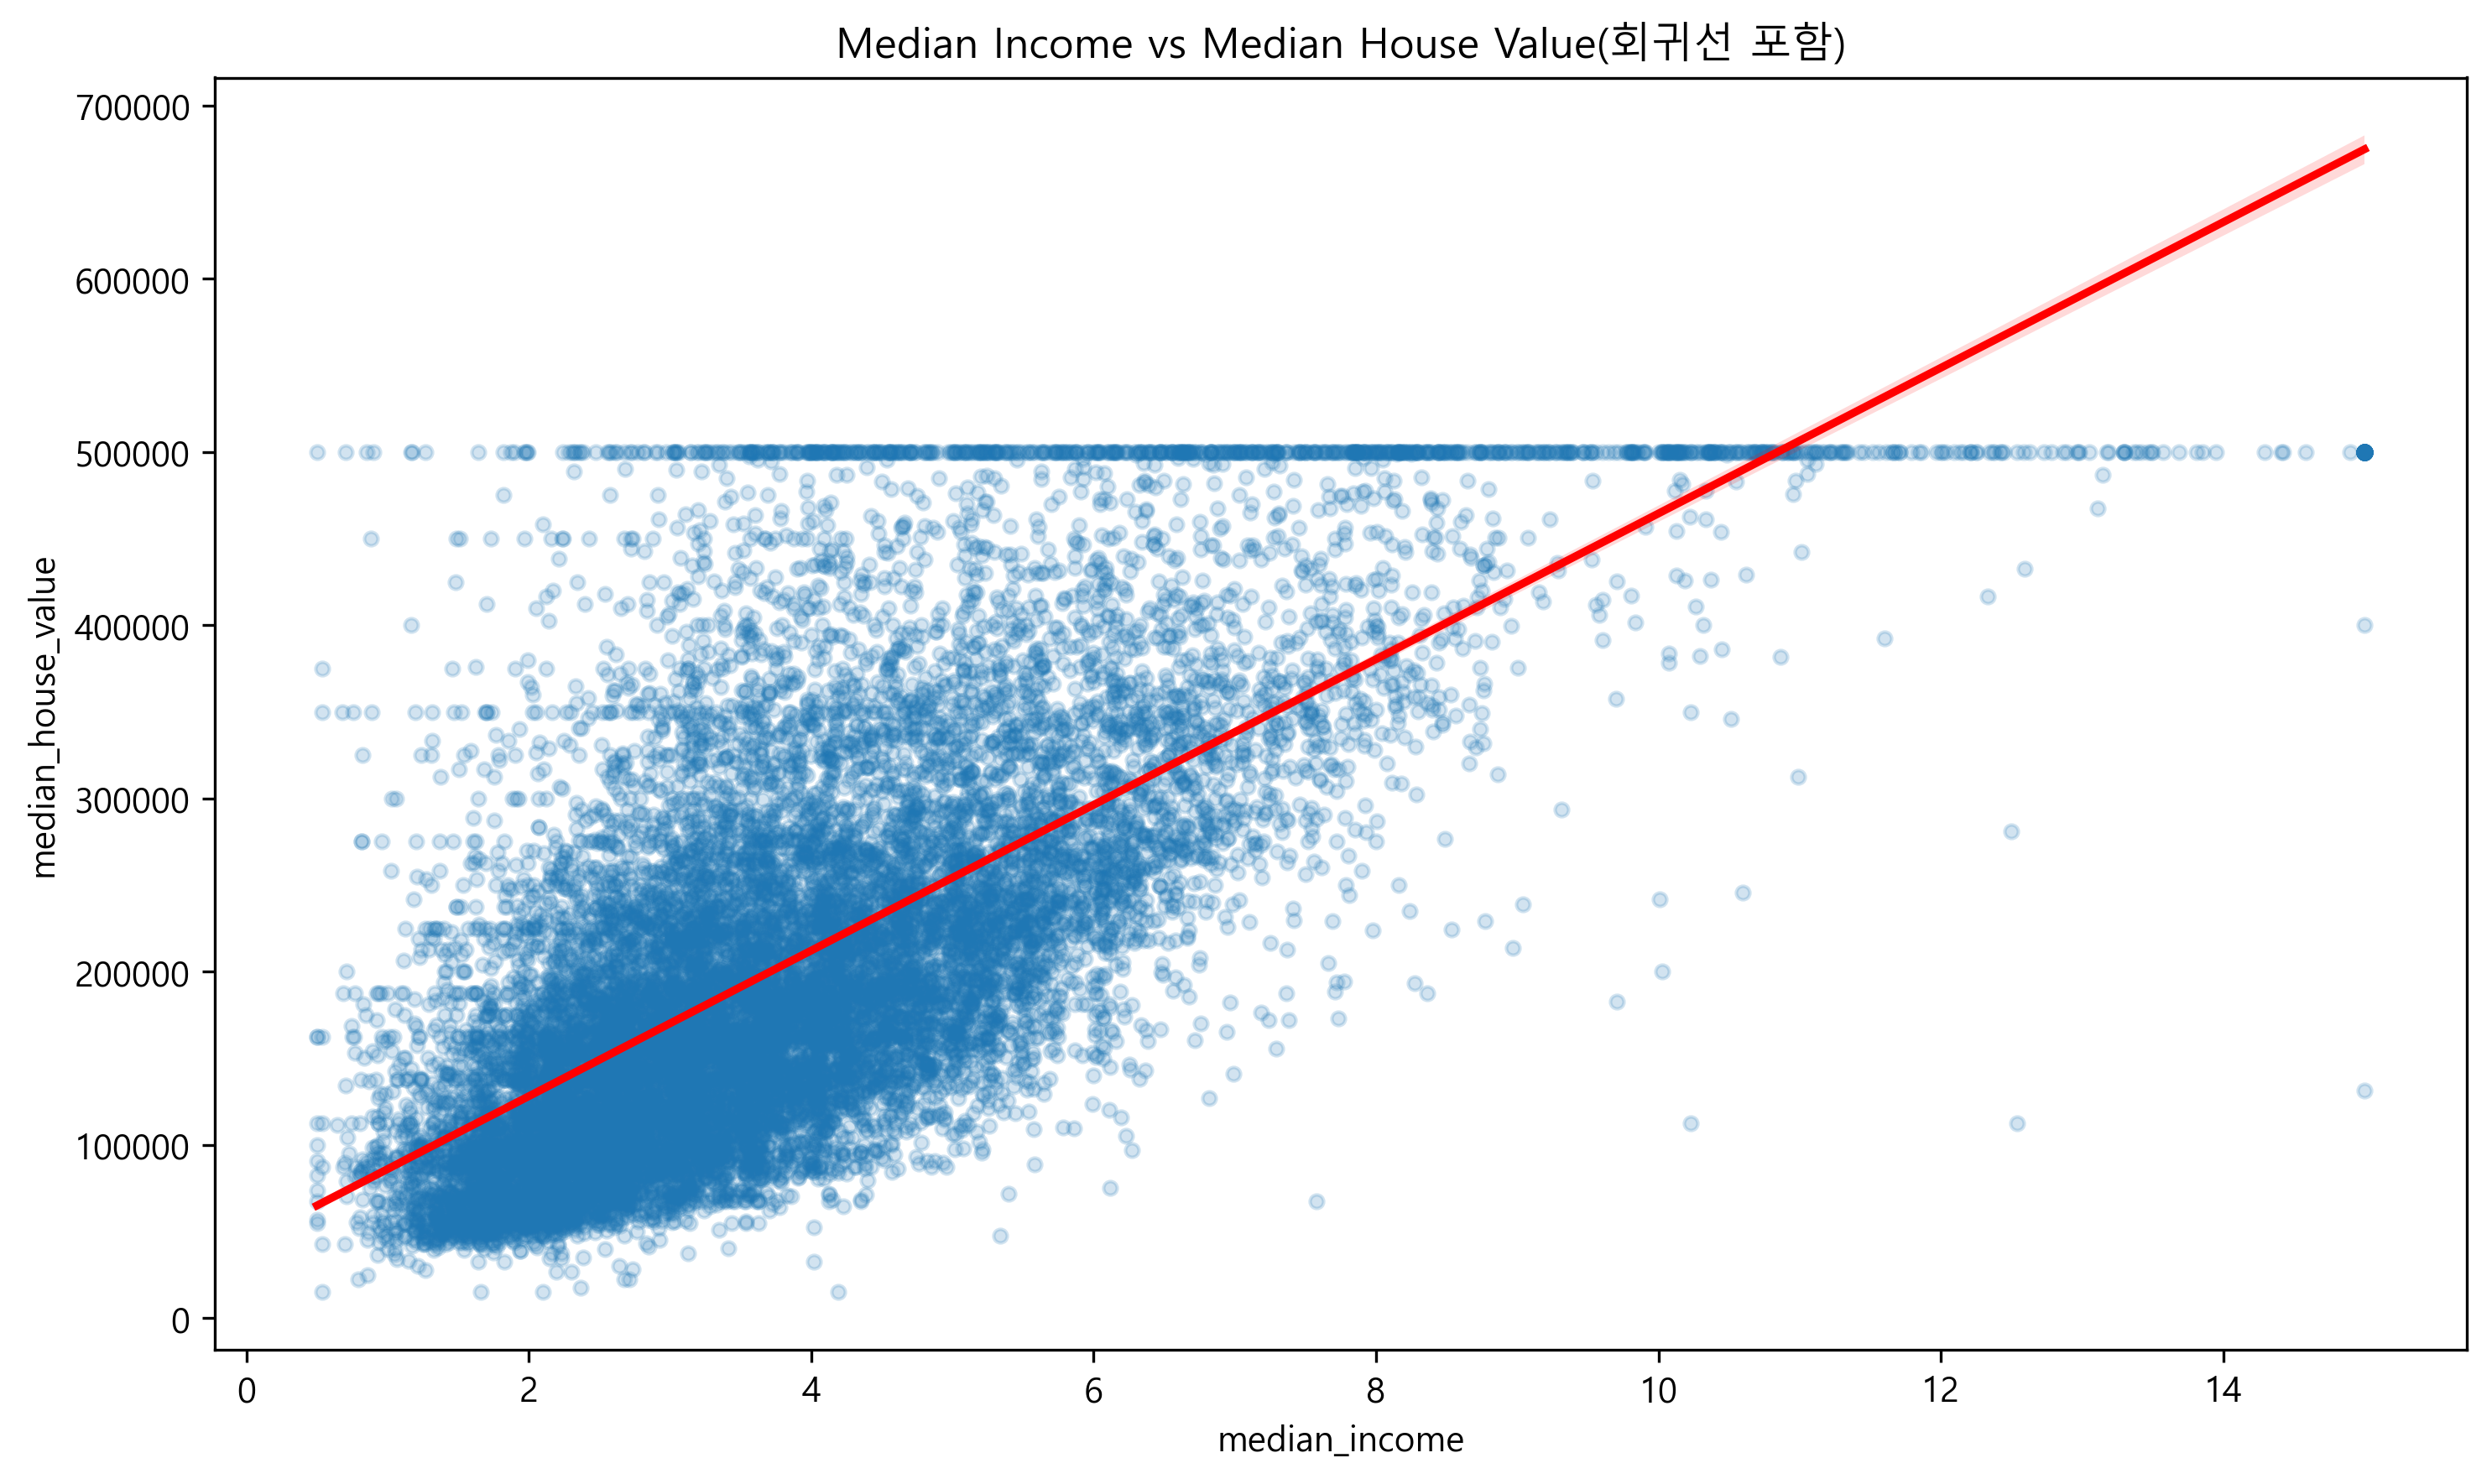

In [10]:
# 산점도 그리기

plt.figure(figsize=(10,6))
sns.regplot(data=df, x='median_income', y='median_house_value',
            scatter_kws={'alpha':0.2, 's':15},
            line_kws={'color':'red'})
plt.title('Median Income vs Median House Value(회귀선 포함)')
plt.tight_layout()
plt.show()

<Figure size 3000x1800 with 0 Axes>

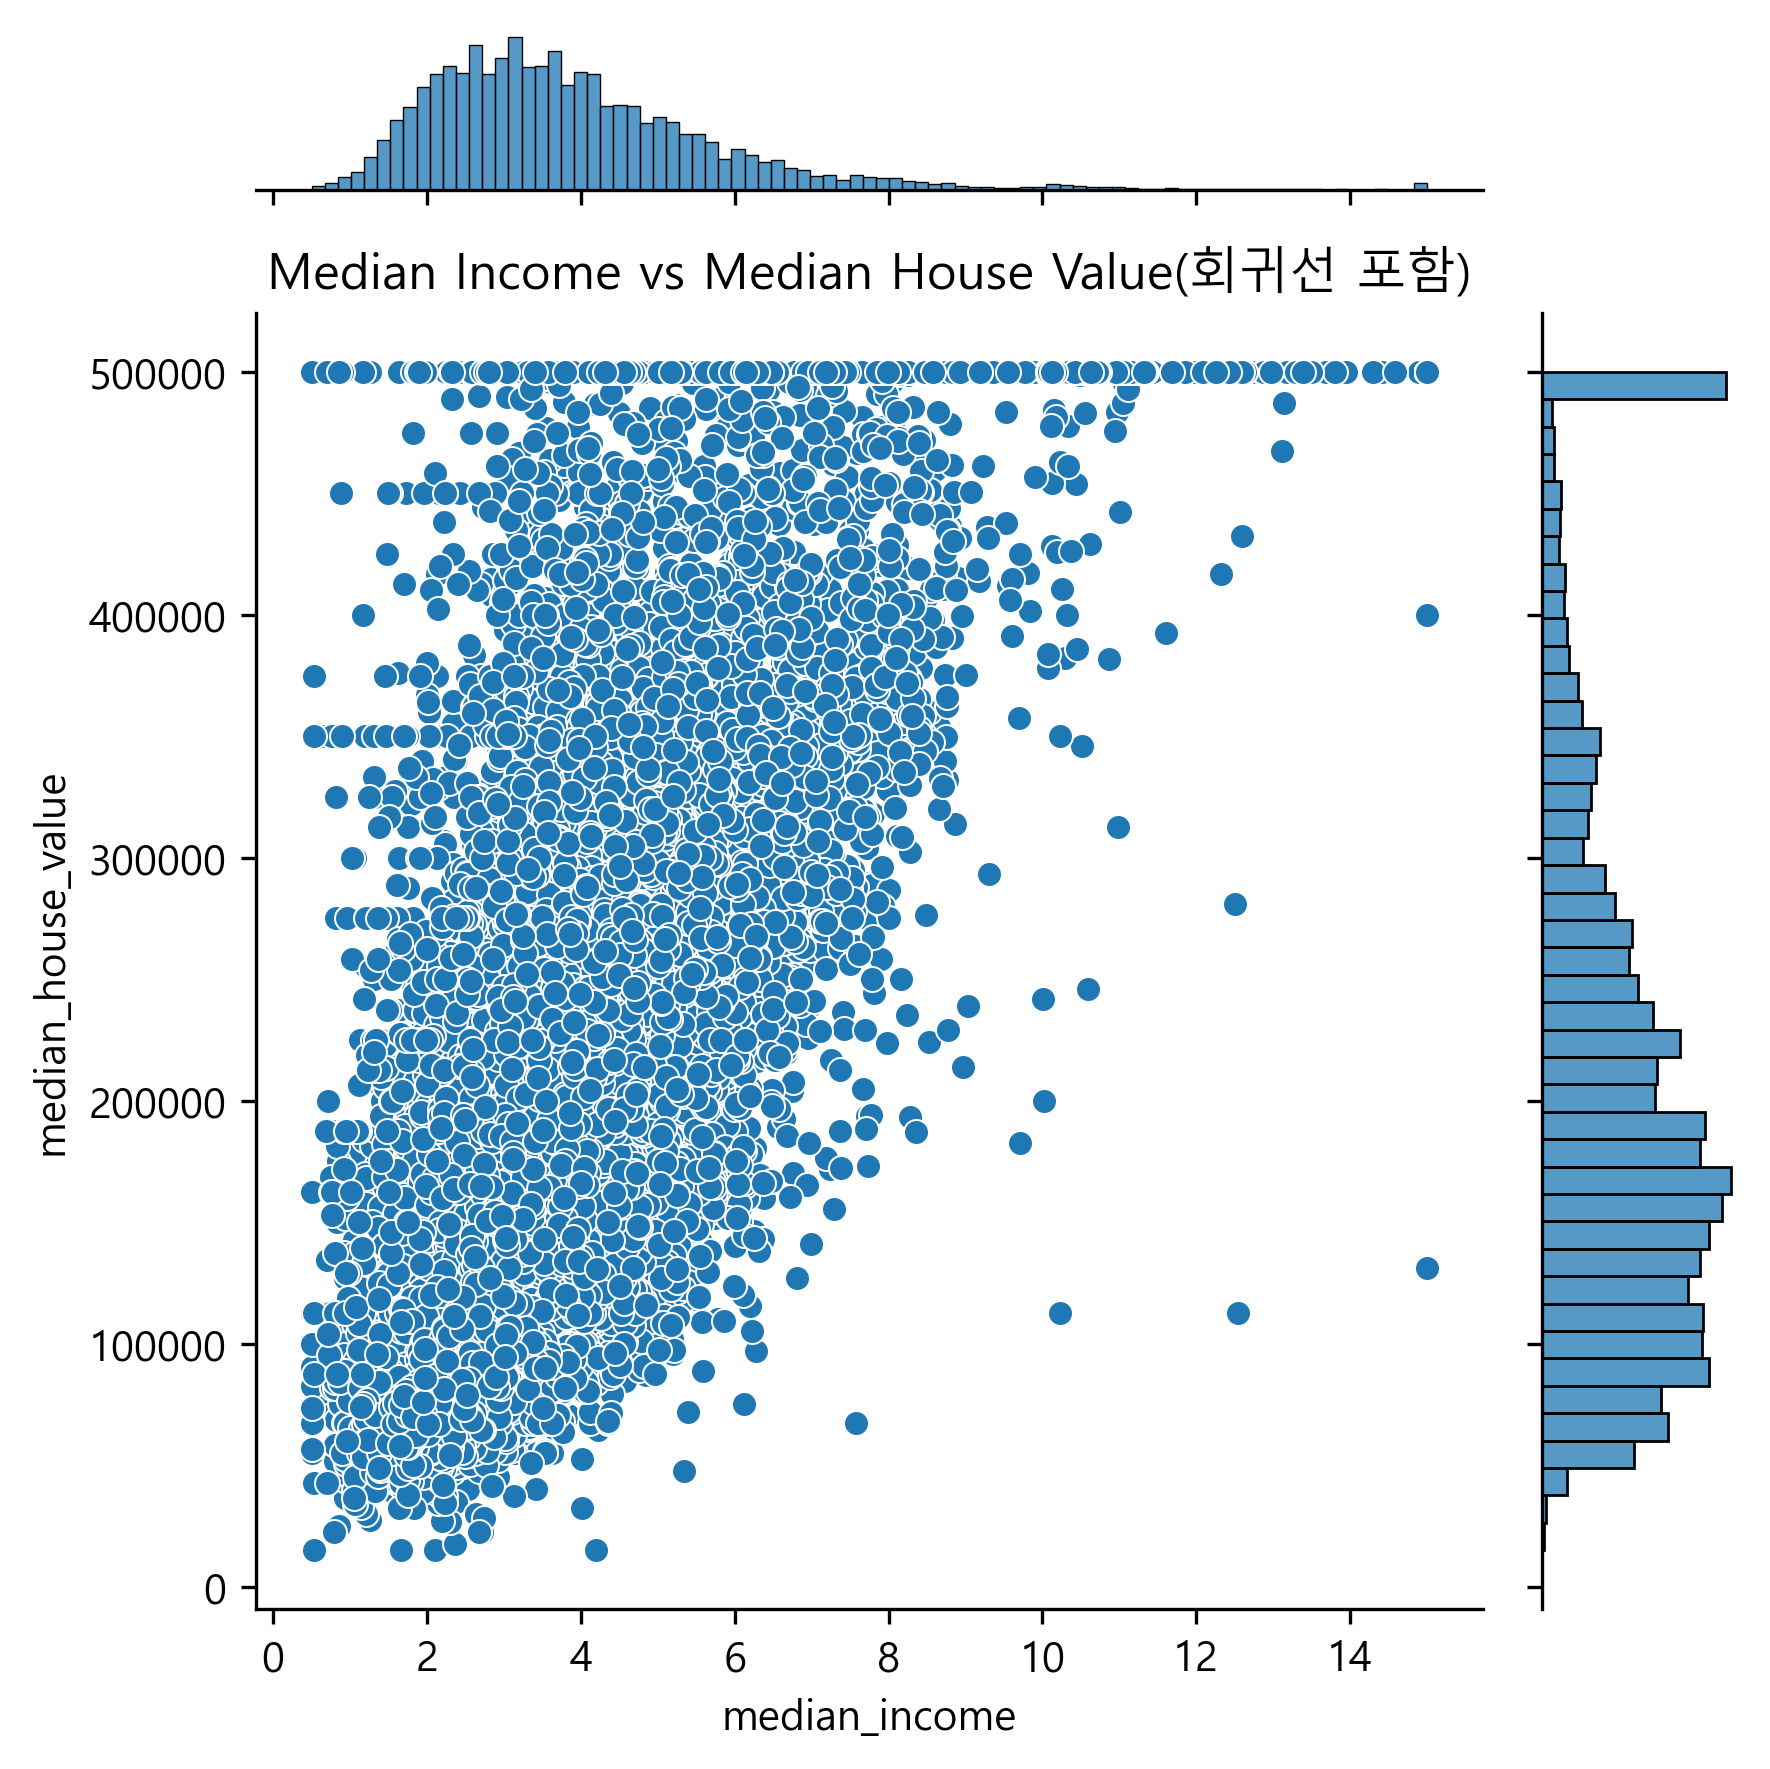

In [11]:
# jointplot: 산점도와 히스토그램 그래프를 같이 그림

plt.figure(figsize=(10,6))
sns.jointplot(data=df, x='median_income', y='median_house_value')
plt.title('Median Income vs Median House Value(회귀선 포함)')
plt.tight_layout()
plt.show()